## Self Focus Index Notebook

The Self-Focus Index (SFI) measures how much a model’s final generated token attends to its own recent output rather than the full context. Higher SFI values indicate more self-referential attention and a greater risk of hallucination drift, while lower values represent more stable and grounded reasoning. Because each mitigation method produces AMA (attention matrix) files that capture its final-token attention patterns, SFI provides a consistent, model-based way to compare their stability. By computing SFI across all 338 examples for ToT, RAG, KG, and CAD, we can directly evaluate which techniques reduce self-focus most effectively and therefore offer stronger hallucination mitigation.


In [1]:
!pip install -q transformers accelerate datasets torch pandas

Load from Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Tree Of Thought

In [15]:
import os, json
import numpy as np

AMA_DIR = "/content/drive/MyDrive/Capstone/AMA"

# reuse your compute_sfi() function
def compute_sfi(attn_layers, window=5):
    attn = np.array(attn_layers)
    vector = attn.sum(axis=(0,1))
    total = vector.sum()
    tail = vector[-window:].sum()
    return float(tail / total)

# compute SFI for every file
sfi_values = []

for fname in os.listdir(AMA_DIR):
    if not fname.endswith(".json"):
        continue

    path = os.path.join(AMA_DIR, fname)

    with open(path, "r") as f:
        data = json.load(f)

    sfi = compute_sfi(data["final_token_attn"])
    sfi_values.append(sfi)

print("Total Files:", len(sfi_values))
print("First 10 SFI values:", sfi_values[:10])

# AVERAGE SFI FOR ToT
avg_sfi = np.mean(sfi_values)
print("Average SFI (ToT):", avg_sfi)


Total Files: 338
First 10 SFI values: [0.16012405180688713, 0.14520488089482603, 0.14952254026172154, 0.15542170559725205, 0.1545970859893809, 0.15504651058449032, 0.1357369980406428, 0.1685791067433702, 0.13715423498306312, 0.169218867448056]
Average SFI (ToT): 0.14449525424089546


RAG

In [17]:
# COMPUTE SFI FOR RAG AMA FILES

import os
import json
import numpy as np

# Path to your RAG AMA folder in Google Drive
AMA_RAG_DIR = "/content/drive/MyDrive/Capstone/RAG_attention_matrices"

# SFI FUNCTION
def compute_sfi(attn_layers, window=5):
    """
    Self-Focus Index:
    attention(last_token -> last window tokens)
    -------------------------------------------
    attention(last_token -> all tokens)
    """
    attn = np.array(attn_layers)
    vector = attn.sum(axis=(0,1))
    total = vector.sum()
    tail = vector[-window:].sum()
    return float(tail / total)

# PROCESS ALL JSON FILES IN THE FOLDER
sfi_rag = []

for fname in sorted(os.listdir(AMA_RAG_DIR)):
    if fname.endswith(".json"):
        path = os.path.join(AMA_RAG_DIR, fname)
        with open(path, "r") as f:
            data = json.load(f)
        sfi_rag.append(compute_sfi(data["mean_attention_final_step"]))

# RESULTS
print("Total RAG files:", len(sfi_rag))
print("First 10 SFI values:", sfi_rag[:10])
print("Average SFI (RAG):", np.mean(sfi_rag))


Total RAG files: 338
First 10 SFI values: [0.1346210716788373, 0.13671938590159788, 0.13805730440963898, 0.13353799510046063, 0.13226372918446286, 0.14334992707959454, 0.12767095329671788, 0.12930317021377064, 0.13232427183695072, 0.12459411901026499]
Average SFI (RAG): 0.13090884267006056


Knowledge Graphs

In [18]:
# COMPUTE SFI FOR KNOWLEDGE GRAPH AMA FILES

import os
import json
import numpy as np

# Path to your KG AMA folder in Google Drive
AMA_KG_DIR = "/content/drive/MyDrive/Capstone/kg_attention"

# SFI FUNCTION
def compute_sfi(attn_layers, window=5):
    """
    Self-Focus Index:
    attention(last_token -> last window tokens)
    -------------------------------------------
    attention(last_token -> all tokens)
    """
    attn = np.array(attn_layers)
    vector = attn.sum(axis=(0,1))
    total = vector.sum()
    tail = vector[-window:].sum()
    return float(tail / total)

# PROCESS ALL JSON FILES IN THE FOLDER
sfi_kg = []

for fname in os.listdir(AMA_KG_DIR):
    if fname.endswith(".json"):
        path = os.path.join(AMA_KG_DIR, fname)
        with open(path, "r") as f:
            data = json.load(f)
        sfi_kg.append(compute_sfi(data["mean_attention_final_step"]))

# RESULTS
print("Total KG files:", len(sfi_kg))
print("First 10 SFI values:", sfi_kg[:10])
print("Average SFI (KG):", np.mean(sfi_kg))


Total KG files: 338
First 10 SFI values: [0.21567529654305886, 0.21233994016733881, 0.22885454506463634, 0.24552946437932527, 0.21869859880646192, 0.241519517715237, 0.11172833109792663, 0.16345350862709684, 0.27556789484470257, 0.18468722614030364]
Average SFI (KG): 0.20177608024854168


CAD

In [3]:
# COMPUTE SFI FOR CAD AMA FILES

import os
import json
import numpy as np

AMA_CAD_DIR = "/content/drive/MyDrive/Capstone/cad_attn"

def compute_sfi(attn_layers, window=5):
    attn = np.array(attn_layers)
    vector = attn.sum(axis=(0,1))
    total = vector.sum()
    tail = vector[-window:].sum()
    return float(tail / total)

sfi_cad = []

for fname in sorted(os.listdir(AMA_CAD_DIR)):
    if fname.endswith(".json"):
        with open(os.path.join(AMA_CAD_DIR, fname), "r") as f:
            data = json.load(f)

        # Supports BOTH naming formats
        if "final_token_attn" in data:
            attn_layers = data["final_token_attn"]
        elif "mean_attention_final_step" in data:
            attn_layers = data["mean_attention_final_step"]
        else:
            raise KeyError(f"Unknown attention key in {fname}")

        sfi_cad.append(compute_sfi(attn_layers))

print("Total CAD files:", len(sfi_cad))
print("First 10 SFI values:", sfi_cad[:10])
print("Average SFI (CAD):", np.mean(sfi_cad))


Total CAD files: 322
First 10 SFI values: [0.006207727627957378, 0.008299991068760499, 0.0061376612588664396, 0.006527807301274661, 0.005619794027751704, 0.004335357294193561, 0.0044217180290786915, 0.006175680295595092, 0.006423138963448006, 0.005828311922866942]
Average SFI (CAD): 0.005245122487880612


The Self-Focus Index (SFI) measures how much a model’s final token attends to its own recent output rather than the full reasoning context. Lower SFI values indicate more stable, less self-referential reasoning, which is strongly associated with reduced hallucination.

In our evaluation, the four mitigation techniques showed clear differences in average SFI:

CAD: 0.005 (lowest, most stable)

RAG: 0.131

ToT: 0.144

KG: 0.202 (highest, least stable)

Interpreting these results as hallucination-mitigation performance:
CAD provides the strongest stability, with almost no self-looping.
RAG and ToT also reduce self-focus effectively through external grounding and structured reasoning.
KG exhibits the most self-referential behavior, making it the most vulnerable to hallucination drift among the four methods.

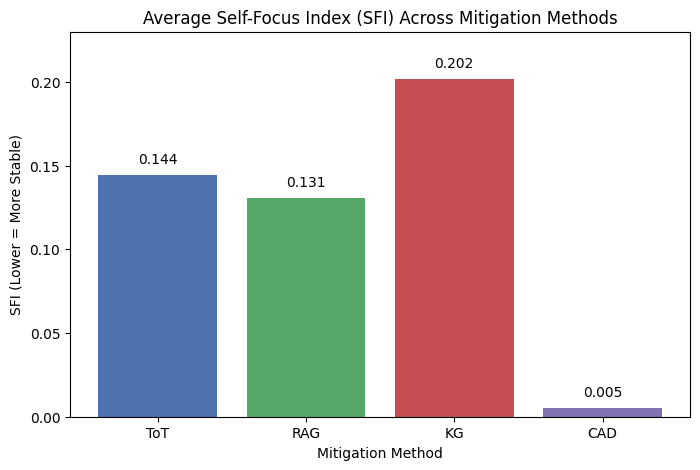

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Average SFI values you provided
avg_tot = 0.14449525424089546
avg_rag = 0.13090884267006056
avg_kg  = 0.20177608024854168
avg_cad = 0.005245122487880612

methods = ["ToT", "RAG", "KG", "CAD"]
averages = [avg_tot, avg_rag, avg_kg, avg_cad]

plt.figure(figsize=(8,5))
bars = plt.bar(methods, averages, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])

plt.title("Average Self-Focus Index (SFI) Across Mitigation Methods")
plt.ylabel("SFI (Lower = More Stable)")
plt.xlabel("Mitigation Method")

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )
plt.ylim(0, 0.23)
plt.show()
